In [2]:
# ============================================================
# NB3 - CELL 1
# SPONSOR DEMO - LOAD PROJECT ARTIFACTS
# ============================================================

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Major_Project/Model/front_camera"
)

MODELS_DIR = PROJECT_DIR / "models"
CONFIG_DIR = PROJECT_DIR / "config"
SCRIPTS_DIR = PROJECT_DIR / "scripts"

print("=" * 75)
print("NB3 - FRONT CAMERA ERGONOMIC MONITORING")
print("=" * 75)

print("\nProject:")
print(PROJECT_DIR)

print("\nModels:")
print(MODELS_DIR)

print("\nConfiguration:")
print(CONFIG_DIR)

print("\nScripts:")
print(SCRIPTS_DIR)

Mounted at /content/drive
NB3 - FRONT CAMERA ERGONOMIC MONITORING

Project:
/content/drive/MyDrive/Major_Project/Model/front_camera

Models:
/content/drive/MyDrive/Major_Project/Model/front_camera/models

Configuration:
/content/drive/MyDrive/Major_Project/Model/front_camera/config

Scripts:
/content/drive/MyDrive/Major_Project/Model/front_camera/scripts


In [5]:
# ============================================================
# NB3 - FIX MISSING FINAL POLICY
# ============================================================

import json
from pathlib import Path

FINAL_POLICY_FILE = (
    CONFIG_DIR /
    "front_camera_final_policy.json"
)

FINAL_POLICY = {

    "distance": {
        "non_safe_min_cm": 40.0,
        "warning_min_cm": 40.0,
        "safe_min_cm": 45.0,
        "safe_max_cm": 75.0,
        "warning_max_cm": 85.0,
        "non_safe_max_cm": 85.0
    },

    "head_pitch": {
        "warning_deg": 15.0,
        "non_safe_deg": 30.0
    },

    "head_yaw": {
        "warning_deg": 15.0,
        "non_safe_deg": 30.0
    },

    "shoulder_tilt": {
        "warning_deg": 10.0,
        "non_safe_deg": 20.0
    },

    "gaze": {
        "enabled": False,
        "reason": (
            "Supporting measurement; not currently used "
            "as an independent safety trigger."
        )
    },

    "blink": {
        "enabled": False,
        "reason": (
            "Informational measurement; not currently used "
            "as an independent safety trigger."
        )
    },

    "head_roll": {
        "enabled": False,
        "reason": (
            "Not used as an independent ergonomic safety trigger."
        )
    },

    "temporal": {
        "warning_seconds": 2.0,
        "non_safe_seconds": 5.0
    }
}

with open(
    FINAL_POLICY_FILE,
    "w"
) as f:
    json.dump(
        FINAL_POLICY,
        f,
        indent=2
    )

print("=" * 75)
print("FINAL POLICY CREATED")
print("=" * 75)

print(
    "File:",
    FINAL_POLICY_FILE
)

print(
    "Exists:",
    FINAL_POLICY_FILE.exists()
)

print("\n✓ Final policy saved to Google Drive.")

FINAL POLICY CREATED
File: /content/drive/MyDrive/Major_Project/Model/front_camera/config/front_camera_final_policy.json
Exists: True

✓ Final policy saved to Google Drive.


In [6]:
# ============================================================
# NB3 - VERIFY FINAL POLICY
# ============================================================

with open(
    FINAL_POLICY_FILE,
    "r"
) as f:
    FINAL_POLICY = json.load(f)

print("=" * 75)
print("FINAL POLICY VERIFIED")
print("=" * 75)

print(
    json.dumps(
        FINAL_POLICY,
        indent=2
    )
)

FINAL POLICY VERIFIED
{
  "distance": {
    "non_safe_min_cm": 40.0,
    "warning_min_cm": 40.0,
    "safe_min_cm": 45.0,
    "safe_max_cm": 75.0,
    "warning_max_cm": 85.0,
    "non_safe_max_cm": 85.0
  },
  "head_pitch": {
    "warning_deg": 15.0,
    "non_safe_deg": 30.0
  },
  "head_yaw": {
    "warning_deg": 15.0,
    "non_safe_deg": 30.0
  },
  "shoulder_tilt": {
    "warning_deg": 10.0,
    "non_safe_deg": 20.0
  },
  "gaze": {
    "enabled": false,
    "reason": "Supporting measurement; not currently used as an independent safety trigger."
  },
  "blink": {
    "enabled": false,
    "reason": "Informational measurement; not currently used as an independent safety trigger."
  },
  "head_roll": {
    "enabled": false,
    "reason": "Not used as an independent ergonomic safety trigger."
  },
  "temporal": {
    "warning_seconds": 2.0,
    "non_safe_seconds": 5.0
  }
}


In [9]:
# ============================================================
# NB3 - FIX: INSTALL DEPENDENCIES
# ============================================================

!pip install -q mediapipe opencv-python numpy pandas scipy matplotlib

print("✓ Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.0 MB/s eta 0:00:00
✓ Dependencies installed.


In [10]:
# ============================================================
# NB3 - VERIFY DEPENDENCIES
# ============================================================

import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp

print("=" * 75)
print("NB3 DEPENDENCY CHECK")
print("=" * 75)

print("Python    :", sys.version.split()[0])
print("OpenCV    :", cv2.__version__)
print("NumPy     :", np.__version__)
print("Pandas    :", pd.__version__)
print("MediaPipe :", mp.__version__)

print("\n✓ All dependencies available.")

NB3 DEPENDENCY CHECK
Python    : 3.12.13
OpenCV    : 5.0.0
NumPy     : 2.0.2
Pandas    : 2.2.2
MediaPipe : 1.0.0

✓ All dependencies available.


In [11]:
# ============================================================
# NB3 - CELL 4
# LOAD FINAL FRONT-CAMERA PIPELINE
# ============================================================

import importlib.util

PIPELINE_FILE = (
    SCRIPTS_DIR /
    "front_camera_pipeline.py"
)

if not PIPELINE_FILE.exists():
    raise FileNotFoundError(
        f"Pipeline not found: {PIPELINE_FILE}"
    )

spec = importlib.util.spec_from_file_location(
    "front_camera_pipeline_final",
    PIPELINE_FILE
)

front_camera_module = (
    importlib.util.module_from_spec(
        spec
    )
)

spec.loader.exec_module(
    front_camera_module
)

FrontCameraPipeline = (
    front_camera_module.FrontCameraPipeline
)

print("=" * 75)
print("FINAL FRONT-CAMERA PIPELINE")
print("=" * 75)

print(
    "Pipeline file:",
    PIPELINE_FILE
)

print(
    "Pipeline class:",
    FrontCameraPipeline
)

print("\n✓ Pipeline module loaded.")

FINAL FRONT-CAMERA PIPELINE
Pipeline file: /content/drive/MyDrive/Major_Project/Model/front_camera/scripts/front_camera_pipeline.py
Pipeline class: <class 'front_camera_pipeline_final.FrontCameraPipeline'>

✓ Pipeline module loaded.


In [12]:
# ============================================================
# NB3 - CELL 5
# INITIALIZE FINAL PIPELINE
# ============================================================

pipeline = FrontCameraPipeline(
    model_dir=MODELS_DIR,
    config_dir=CONFIG_DIR
)

print("=" * 75)
print("PIPELINE INITIALIZED")
print("=" * 75)

print("✓ Face Landmarker")
print("✓ Pose Landmarker")
print("✓ Distance calibration")
print("✓ Reference calibration")
print("✓ Safety configuration")

print("\n✓ SYSTEM READY")

PIPELINE INITIALIZED
✓ Face Landmarker
✓ Pose Landmarker
✓ Distance calibration
✓ Reference calibration
✓ Safety configuration

✓ SYSTEM READY


In [13]:
# ============================================================
# NB3 - CELL 6
# ROBUST WEBCAM FRAME CAPTURE
# ============================================================

from google.colab import output
import base64
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt


def capture_webcam_frame():

    js_code = r"""
    (async () => {

        const video =
            document.createElement("video");

        video.setAttribute(
            "autoplay",
            ""
        );

        video.setAttribute(
            "playsinline",
            ""
        );

        video.muted = true;

        video.style.position = "fixed";
        video.style.left = "-10000px";
        video.style.top = "-10000px";
        video.style.width = "1px";
        video.style.height = "1px";

        document.body.appendChild(video);

        let stream = null;

        try {

            stream =
                await navigator.mediaDevices.getUserMedia({
                    video: {
                        facingMode: "user",
                        width: { ideal: 1280 },
                        height: { ideal: 720 }
                    },
                    audio: false
                });

            video.srcObject = stream;

            await video.play();

            await new Promise(resolve => {

                if (
                    video.videoWidth > 0 &&
                    video.videoHeight > 0
                ) {
                    resolve();
                    return;
                }

                video.onloadedmetadata =
                    () => resolve();
            });

            await new Promise(
                resolve =>
                setTimeout(resolve, 300)
            );

            const canvas =
                document.createElement("canvas");

            canvas.width =
                video.videoWidth;

            canvas.height =
                video.videoHeight;

            const ctx =
                canvas.getContext("2d");

            ctx.drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

            return canvas.toDataURL(
                "image/jpeg",
                0.85
            );

        } finally {

            if (stream !== null) {

                stream
                    .getTracks()
                    .forEach(
                        track =>
                        track.stop()
                    );
            }

            video.remove();
        }

    })()
    """

    encoded = output.eval_js(
        js_code
    )

    if not isinstance(
        encoded,
        str
    ):
        raise RuntimeError(
            "Webcam did not return image data."
        )

    _, encoded_data = (
        encoded.split(",", 1)
    )

    image_bytes = base64.b64decode(
        encoded_data
    )

    image_array = np.frombuffer(
        image_bytes,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    if frame is None:
        raise RuntimeError(
            "Could not decode webcam frame."
        )

    return frame


print(
    "✓ Webcam capture function ready."
)

✓ Webcam capture function ready.


In [15]:
# ============================================================
# NB3 - CELL 7
# SINGLE FRAME DEMO TEST
# ============================================================

print("=" * 75)
print("SPONSOR DEMO - SINGLE FRAME TEST")
print("=" * 75)

frame = capture_webcam_frame()

result = pipeline.process_frame(
    frame
)

print(
    "\nFace detected:",
    result.get(
        "face_detected",
        False
    )
)

print(
    "Pose detected:",
    result.get(
        "pose_detected",
        False
    )
)

print(
    "Distance:",
    result.get(
        "estimated_distance_cm",
        np.nan
    )
)

print(
    "Head pitch:",
    result.get(
        "head_pitch_deg",
        np.nan
    )
)

print(
    "Head yaw:",
    result.get(
        "head_yaw_deg",
        np.nan
    )
)

print(
    "Shoulder tilt:",
    result.get(
        "shoulder_tilt_deg",
        np.nan
    )
)

print(
    "Eye openness:",
    result.get(
        "mean_eye_open_ratio",
        np.nan
    )
)

print(
    "Blink count:",
    result.get(
        "blink_count",
        0
    )
)

SPONSOR DEMO - SINGLE FRAME TEST

Face detected: True
Pose detected: True
Distance: 55.642008405476176
Head pitch: 0.34787046909332275
Head yaw: 2.897528886795044
Shoulder tilt: 0.8836948562606664
Eye openness: 0.5056483533066035
Blink count: 0


In [16]:
# ============================================================
# NB3 - CELL 8
# SPONSOR DEMO SAFETY ENGINE
# ============================================================

class SponsorTemporalState:

    def __init__(
        self,
        warning_seconds=2.0,
        non_safe_seconds=5.0
    ):

        self.warning_seconds = float(
            warning_seconds
        )

        self.non_safe_seconds = float(
            non_safe_seconds
        )

        self.violation_start = None
        self.status = "SAFE"


    def update(
        self,
        frame_status,
        timestamp
    ):

        if frame_status == "SAFE":

            self.violation_start = None
            self.status = "SAFE"

            return self.status

        if frame_status == "UNKNOWN":

            return self.status

        if self.violation_start is None:

            self.violation_start = timestamp

            self.status = "SAFE"

            return self.status

        elapsed = (
            timestamp -
            self.violation_start
        )

        if (
            frame_status == "NON-SAFE"
            and
            elapsed >=
            self.non_safe_seconds
        ):

            self.status = "NON-SAFE"

            return self.status

        if (
            elapsed >=
            self.warning_seconds
        ):

            self.status = "WARNING"

        else:

            self.status = "SAFE"

        return self.status


sponsor_temporal = SponsorTemporalState(
    warning_seconds=FINAL_POLICY[
        "temporal"
    ][
        "warning_seconds"
    ],
    non_safe_seconds=FINAL_POLICY[
        "temporal"
    ][
        "non_safe_seconds"
    ]
)


def sponsor_frame_decision(
    result
):

    if not result.get(
        "face_detected",
        False
    ):

        return {
            "frame_status": "UNKNOWN",
            "reasons": [
                "Face not detected"
            ]
        }

    if not result.get(
        "pose_detected",
        False
    ):

        return {
            "frame_status": "UNKNOWN",
            "reasons": [
                "Upper body not detected"
            ]
        }


    reasons = []
    non_safe = False
    warning = False


    # --------------------------------------------------------
    # Distance
    # --------------------------------------------------------

    distance = result.get(
        "estimated_distance_cm",
        np.nan
    )

    d = FINAL_POLICY[
        "distance"
    ]

    if not pd.isna(distance):

        if distance < d[
            "non_safe_min_cm"
        ]:

            non_safe = True

            reasons.append(
                "Too close to screen"
            )

        elif distance < d[
            "safe_min_cm"
        ]:

            warning = True

            reasons.append(
                "Slightly too close"
            )

        elif distance > d[
            "non_safe_max_cm"
        ]:

            non_safe = True

            reasons.append(
                "Too far from screen"
            )

        elif distance > d[
            "safe_max_cm"
        ]:

            warning = True

            reasons.append(
                "Slightly too far"
            )


    # --------------------------------------------------------
    # Head pitch
    # --------------------------------------------------------

    if "head_pitch_deg" in result:

        ref = float(
            pipeline.reference.get(
                "head_pitch_deg",
                0.0
            )
        )

        deviation = abs(
            result[
                "head_pitch_deg"
            ] -
            ref
        )

        rule = FINAL_POLICY[
            "head_pitch"
        ]

        if deviation >= rule[
            "non_safe_deg"
        ]:

            non_safe = True

            reasons.append(
                "Severe head pitch deviation"
            )

        elif deviation >= rule[
            "warning_deg"
        ]:

            warning = True

            reasons.append(
                "Head position needs attention"
            )


    # --------------------------------------------------------
    # Head yaw
    # --------------------------------------------------------

    if "head_yaw_deg" in result:

        ref = float(
            pipeline.reference.get(
                "head_yaw_deg",
                0.0
            )
        )

        deviation = abs(
            result[
                "head_yaw_deg"
            ] -
            ref
        )

        rule = FINAL_POLICY[
            "head_yaw"
        ]

        if deviation >= rule[
            "non_safe_deg"
        ]:

            non_safe = True

            reasons.append(
                "Severe head turn"
            )

        elif deviation >= rule[
            "warning_deg"
        ]:

            warning = True

            reasons.append(
                "Head turned away"
            )


    # --------------------------------------------------------
    # Shoulder alignment
    # --------------------------------------------------------

    if "shoulder_tilt_deg" in result:

        ref = float(
            pipeline.reference.get(
                "shoulder_tilt_deg",
                0.0
            )
        )

        deviation = abs(
            result[
                "shoulder_tilt_deg"
            ] -
            ref
        )

        rule = FINAL_POLICY[
            "shoulder_tilt"
        ]

        if deviation >= rule[
            "non_safe_deg"
        ]:

            non_safe = True

            reasons.append(
                "Significant shoulder misalignment"
            )

        elif deviation >= rule[
            "warning_deg"
        ]:

            warning = True

            reasons.append(
                "Shoulder alignment needs attention"
            )


    if non_safe:

        frame_status = "NON-SAFE"

    elif warning:

        frame_status = "WARNING"

    else:

        frame_status = "SAFE"


    return {
        "frame_status": frame_status,
        "reasons": reasons
    }


def sponsor_decision(
    result,
    timestamp
):

    frame = sponsor_frame_decision(
        result
    )

    final_status = (
        sponsor_temporal.update(
            frame[
                "frame_status"
            ],
            timestamp
        )
    )

    return {

        "frame_status":
            frame[
                "frame_status"
            ],

        "final_status":
            final_status,

        "reasons":
            frame[
                "reasons"
            ]
    }


print(
    "✓ Sponsor safety engine ready."
)

✓ Sponsor safety engine ready.


In [17]:
# ============================================================
# NB3 - CELL 9
# SPONSOR-FACING FRAME ANNOTATION
# ============================================================

def annotate_sponsor_frame(
    frame,
    result,
    decision
):

    output = frame.copy()

    status = decision[
        "final_status"
    ]

    if status == "SAFE":

        color = (
            40,
            180,
            40
        )

    elif status == "WARNING":

        color = (
            0,
            180,
            255
        )

    elif status == "NON-SAFE":

        color = (
            0,
            0,
            220
        )

    else:

        color = (
            120,
            120,
            120
        )


    # --------------------------------------------------------
    # Status banner
    # --------------------------------------------------------

    cv2.rectangle(
        output,
        (0, 0),
        (
            output.shape[1],
            78
        ),
        color,
        -1
    )

    cv2.putText(
        output,
        f"STATUS: {status}",
        (25, 52),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.25,
        (255, 255, 255),
        3,
        cv2.LINE_AA
    )


    # --------------------------------------------------------
    # Measurements
    # --------------------------------------------------------

    measurements = [

        (
            "Distance",
            result.get(
                "estimated_distance_cm",
                np.nan
            ),
            "cm"
        ),

        (
            "Head Pitch",
            result.get(
                "head_pitch_deg",
                np.nan
            ),
            "deg"
        ),

        (
            "Head Yaw",
            result.get(
                "head_yaw_deg",
                np.nan
            ),
            "deg"
        ),

        (
            "Shoulder Tilt",
            result.get(
                "shoulder_tilt_deg",
                np.nan
            ),
            "deg"
        ),

        (
            "Eye Openness",
            result.get(
                "mean_eye_open_ratio",
                np.nan
            ),
            ""
        ),

        (
            "Blink Count",
            result.get(
                "blink_count",
                0
            ),
            ""
        )
    ]


    y = 125

    for name, value, unit in measurements:

        if pd.isna(value):

            text = (
                f"{name}: unavailable"
            )

        elif unit == "cm":

            text = (
                f"{name}: "
                f"{float(value):.1f} cm"
            )

        elif unit == "deg":

            text = (
                f"{name}: "
                f"{float(value):.1f}°"
            )

        else:

            text = (
                f"{name}: "
                f"{float(value):.3f}"
            )

        cv2.putText(
            output,
            text,
            (25, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        y += 36


    # --------------------------------------------------------
    # Reasons
    # --------------------------------------------------------

    reasons = decision[
        "reasons"
    ]

    if reasons:

        reason_text = (
            " | ".join(
                reasons
            )
        )

        cv2.putText(
            output,
            reason_text,
            (
                25,
                output.shape[0] - 25
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )


    return output


print(
    "✓ Sponsor annotation ready."
)

✓ Sponsor annotation ready.


SPONSOR DEMO RESULT
Frame status: SAFE
Final status: SAFE
Reasons: []


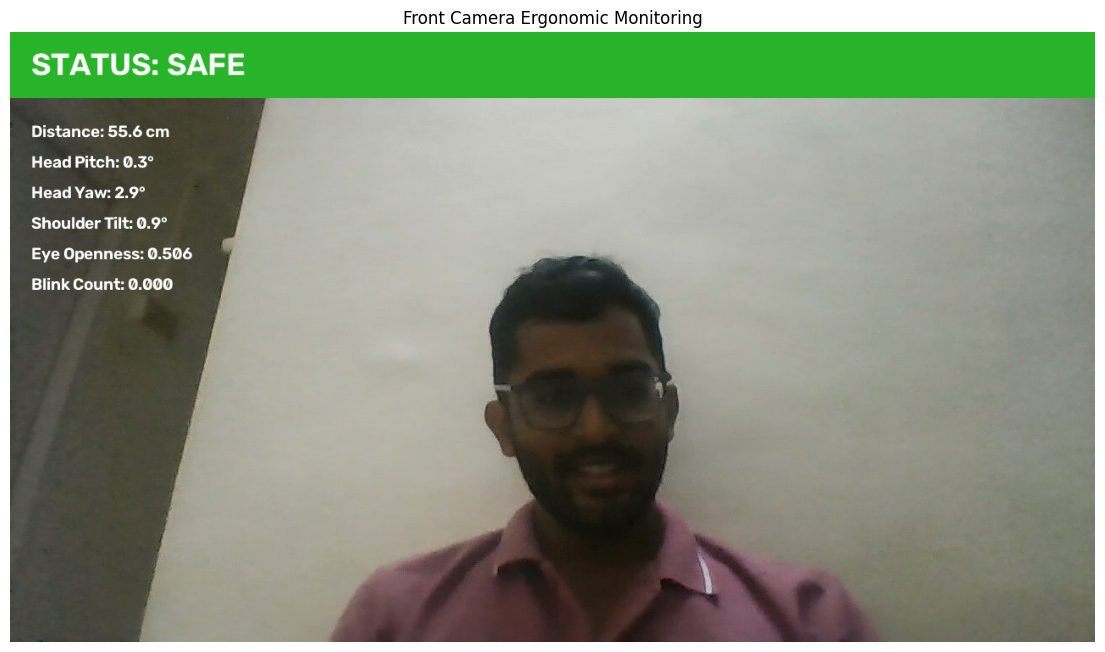

In [18]:
# ============================================================
# NB3 - CELL 10
# SPONSOR DEMO FRAME
# ============================================================

timestamp = time.time()

decision = sponsor_decision(
    result,
    timestamp
)

annotated = annotate_sponsor_frame(
    frame,
    result,
    decision
)

print("=" * 75)
print("SPONSOR DEMO RESULT")
print("=" * 75)

print(
    "Frame status:",
    decision[
        "frame_status"
    ]
)

print(
    "Final status:",
    decision[
        "final_status"
    ]
)

print(
    "Reasons:",
    decision[
        "reasons"
    ]
)

plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    "Front Camera Ergonomic Monitoring"
)

plt.show()

In [23]:
# ============================================================
# NB3 - CELL 11
# ROBUST WEBCAM CAPTURE
# ============================================================

from google.colab import output
from IPython.display import clear_output

import base64
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt


def capture_sponsor_frame():

    js_code = r"""
    (async () => {

        const video =
            document.createElement("video");

        video.setAttribute("autoplay", "");
        video.setAttribute("playsinline", "");
        video.muted = true;

        video.style.position = "fixed";
        video.style.left = "-10000px";
        video.style.top = "-10000px";
        video.style.width = "1px";
        video.style.height = "1px";

        document.body.appendChild(video);

        let stream = null;

        try {

            stream =
                await navigator.mediaDevices.getUserMedia({
                    video: {
                        facingMode: "user",
                        width: { ideal: 1280 },
                        height: { ideal: 720 }
                    },
                    audio: false
                });

            video.srcObject = stream;

            await video.play();

            await new Promise(resolve => {

                if (
                    video.videoWidth > 0 &&
                    video.videoHeight > 0
                ) {
                    resolve();
                    return;
                }

                video.onloadedmetadata =
                    () => resolve();
            });

            await new Promise(
                resolve => setTimeout(resolve, 300)
            );

            const canvas =
                document.createElement("canvas");

            canvas.width =
                video.videoWidth;

            canvas.height =
                video.videoHeight;

            const ctx =
                canvas.getContext("2d");

            ctx.drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

            return canvas.toDataURL(
                "image/jpeg",
                0.85
            );

        } finally {

            if (stream !== null) {

                stream
                    .getTracks()
                    .forEach(
                        track => track.stop()
                    );
            }

            video.remove();
        }

    })()
    """

    encoded = output.eval_js(js_code)

    if not isinstance(encoded, str):
        raise RuntimeError(
            "Webcam did not return image data."
        )

    _, encoded_data = encoded.split(",", 1)

    image_bytes = base64.b64decode(
        encoded_data
    )

    image_array = np.frombuffer(
        image_bytes,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    if frame is None:
        raise RuntimeError(
            "Could not decode webcam frame."
        )

    return frame


print("✓ Robust sponsor webcam capture ready.")

✓ Robust sponsor webcam capture ready.


In [24]:
# ============================================================
# NB3 - CELL 12
# SPONSOR CAMERA + PIPELINE TEST
# ============================================================

print("=" * 75)
print("SPONSOR LIVE SYSTEM TEST")
print("=" * 75)

frame = capture_sponsor_frame()

print(
    "Frame shape:",
    frame.shape
)

result = pipeline.process_frame(
    frame
)

timestamp = time.time()

decision = sponsor_decision(
    result,
    timestamp
)

print("\n" + "=" * 75)
print("RESULT")
print("=" * 75)

print(
    "Status:",
    decision["final_status"]
)

print(
    "Distance:",
    result.get(
        "estimated_distance_cm",
        np.nan
    )
)

print(
    "Head pitch:",
    result.get(
        "head_pitch_deg",
        np.nan
    )
)

print(
    "Head yaw:",
    result.get(
        "head_yaw_deg",
        np.nan
    )
)

print(
    "Shoulder tilt:",
    result.get(
        "shoulder_tilt_deg",
        np.nan
    )
)

print(
    "Eye openness:",
    result.get(
        "mean_eye_open_ratio",
        np.nan
    )
)

print(
    "Blink count:",
    result.get(
        "blink_count",
        0
    )
)

print(
    "Reasons:",
    decision["reasons"]
)

SPONSOR LIVE SYSTEM TEST
Frame shape: (720, 1280, 3)

RESULT
Status: SAFE
Distance: 55.86694702248838
Head pitch: 2.135877847671509
Head yaw: -0.12471824884414673
Shoulder tilt: 1.0011373205386946
Eye openness: 0.4878238615195746
Blink count: 0
Reasons: []


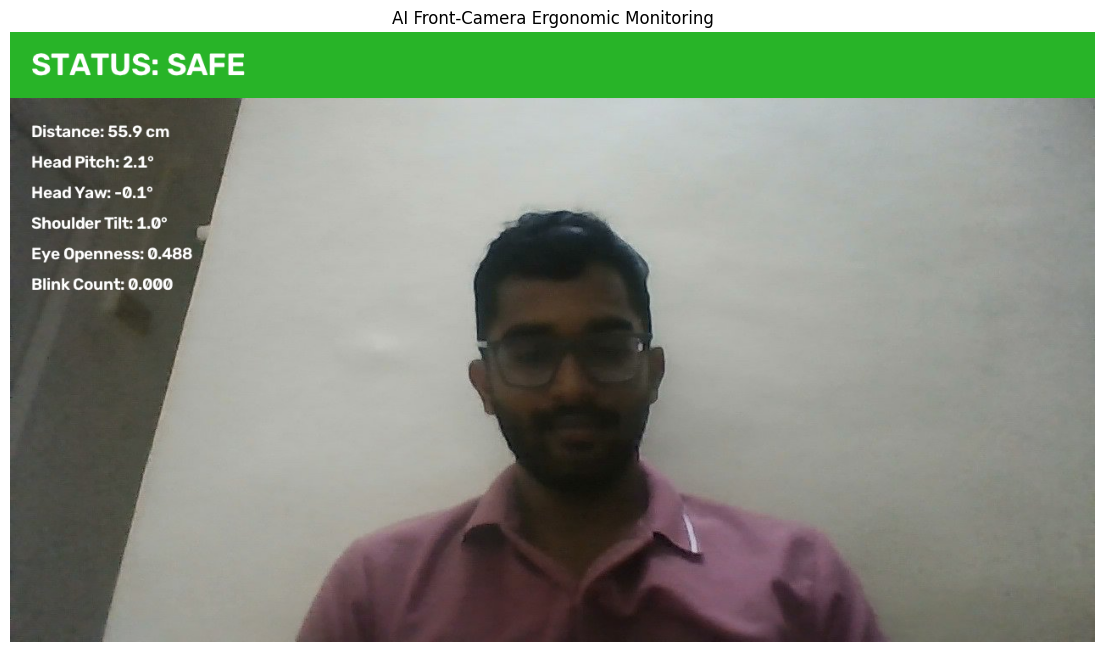

In [25]:
# ============================================================
# NB3 - CELL 13
# SPONSOR-FACING ANNOTATED FRAME
# ============================================================

annotated = annotate_sponsor_frame(
    frame,
    result,
    decision
)

plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    "AI Front-Camera Ergonomic Monitoring"
)

plt.show()

In [29]:
# ============================================================
# NB3 - CELL 14A
# START PERSISTENT CAMERA FOR LIVE DEMO
# ============================================================

from IPython.display import display, Javascript
from google.colab import output

display(
    Javascript(r"""
    window.nb3Camera = {
        video: null,
        stream: null,
        canvas: null,
        ready: false
    };

    window.nb3StartCamera = async function() {

        if (window.nb3Camera.ready) {
            return true;
        }

        const video = document.createElement("video");

        video.autoplay = true;
        video.playsInline = true;
        video.muted = true;

        video.style.position = "fixed";
        video.style.right = "15px";
        video.style.bottom = "15px";
        video.style.width = "320px";
        video.style.zIndex = "99999";
        video.style.border = "2px solid white";

        document.body.appendChild(video);

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: {
                    facingMode: "user",
                    width: {
                        ideal: 1280
                    },
                    height: {
                        ideal: 720
                    }
                },
                audio: false
            });

        video.srcObject = stream;

        await video.play();

        await new Promise(resolve => {

            if (
                video.videoWidth > 0 &&
                video.videoHeight > 0
            ) {
                resolve();
            } else {
                video.onloadedmetadata = resolve;
            }
        });

        const canvas =
            document.createElement("canvas");

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        window.nb3Camera.video = video;
        window.nb3Camera.stream = stream;
        window.nb3Camera.canvas = canvas;
        window.nb3Camera.ready = true;

        return true;
    };

    window.nb3GetFrame = function() {

        if (!window.nb3Camera.ready) {
            throw new Error("Camera not started");
        }

        const video = window.nb3Camera.video;
        const canvas = window.nb3Camera.canvas;

        const ctx = canvas.getContext("2d");

        ctx.drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        return canvas.toDataURL(
            "image/jpeg",
            0.75
        );
    };

    window.nb3StopCamera = function() {

        if (window.nb3Camera.stream) {

            window.nb3Camera.stream
                .getTracks()
                .forEach(
                    track => track.stop()
                );
        }

        if (window.nb3Camera.video) {
            window.nb3Camera.video.remove();
        }

        window.nb3Camera = {
            video: null,
            stream: null,
            canvas: null,
            ready: false
        };

        return true;
    };
    """)
)

started = output.eval_js(
    "nb3StartCamera()"
)

print(
    "Camera started:",
    started
)

<IPython.core.display.Javascript object>

Camera started: True


In [31]:
# ============================================================
# NB3 - CELL 14
# LIVE CAMERA BATCH CAPTURE
# NO PERSISTENT window.* FUNCTIONS
# ============================================================

from google.colab import output
from IPython.display import clear_output

import base64
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt


def capture_live_batch(
    frame_count=5,
    fps=10,
    jpeg_quality=0.70
):

    delay_ms = int(
        1000 / fps
    )

    js_code = f"""
    (async () => {{

        const video =
            document.createElement("video");

        video.autoplay = true;
        video.playsInline = true;
        video.muted = true;

        video.style.position = "fixed";
        video.style.right = "15px";
        video.style.bottom = "15px";
        video.style.width = "320px";
        video.style.height = "180px";
        video.style.zIndex = "99999";
        video.style.border = "3px solid white";
        video.style.background = "black";

        document.body.appendChild(video);

        let stream = null;

        try {{

            stream =
                await navigator.mediaDevices.getUserMedia({{
                    video: {{
                        facingMode: "user",
                        width: {{ ideal: 1280 }},
                        height: {{ ideal: 720 }}
                    }},
                    audio: false
                }});

            video.srcObject = stream;

            await video.play();

            await new Promise(resolve => {{

                if (
                    video.videoWidth > 0 &&
                    video.videoHeight > 0
                ) {{
                    resolve();
                }} else {{
                    video.onloadedmetadata = () => resolve();
                }}

            }});

            const canvas =
                document.createElement("canvas");

            canvas.width =
                video.videoWidth;

            canvas.height =
                video.videoHeight;

            const ctx =
                canvas.getContext("2d");

            const frames = [];

            for (
                let i = 0;
                i < {frame_count};
                i++
            ) {{

                ctx.drawImage(
                    video,
                    0,
                    0,
                    canvas.width,
                    canvas.height
                );

                frames.push(
                    canvas.toDataURL(
                        "image/jpeg",
                        {jpeg_quality}
                    )
                );

                await new Promise(
                    resolve =>
                    setTimeout(
                        resolve,
                        {delay_ms}
                    )
                );
            }}

            return frames;

        }} finally {{

            if (stream !== null) {{
                stream
                    .getTracks()
                    .forEach(
                        track =>
                        track.stop()
                    );
            }}

            video.remove();
        }}

    }})()
    """

    encoded_frames = output.eval_js(
        js_code
    )

    decoded = []

    for encoded in encoded_frames:

        _, encoded_data = (
            encoded.split(",", 1)
        )

        image_bytes = base64.b64decode(
            encoded_data
        )

        frame = cv2.imdecode(
            np.frombuffer(
                image_bytes,
                dtype=np.uint8
            ),
            cv2.IMREAD_COLOR
        )

        if frame is not None:
            decoded.append(frame)

    return decoded


print(
    "✓ Batch webcam capture ready."
)

✓ Batch webcam capture ready.


CAMERA BATCH TEST
Frames captured: 5
Frame shape: (720, 1280, 3)


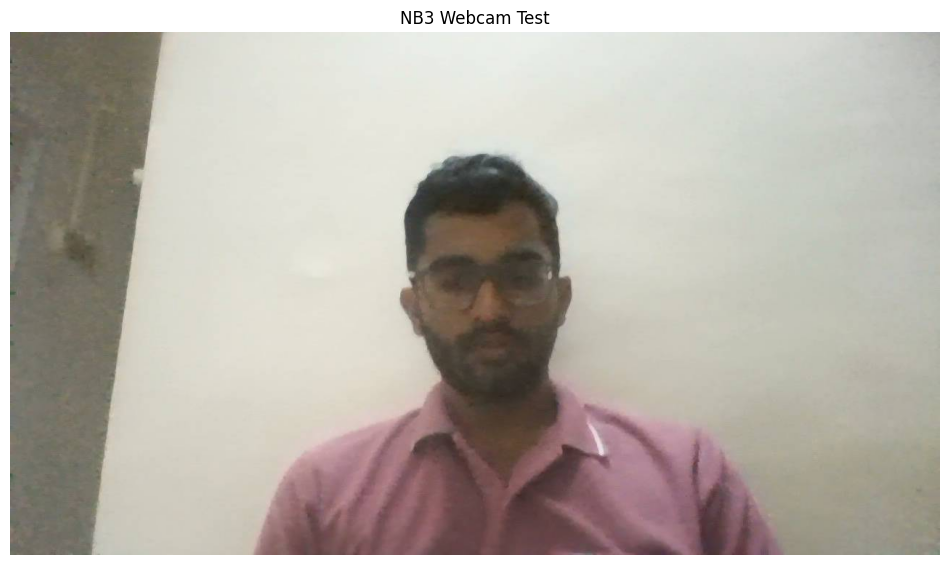

In [32]:
# ============================================================
# NB3 - CELL 15
# TEST BATCH CAPTURE
# ============================================================

print("=" * 75)
print("CAMERA BATCH TEST")
print("=" * 75)

test_frames = capture_live_batch(
    frame_count=5,
    fps=5
)

print(
    "Frames captured:",
    len(test_frames)
)

if len(test_frames) == 0:
    raise RuntimeError(
        "No webcam frames captured."
    )

print(
    "Frame shape:",
    test_frames[0].shape
)

plt.figure(
    figsize=(12, 7)
)

plt.imshow(
    cv2.cvtColor(
        test_frames[-1],
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title(
    "NB3 Webcam Test"
)
plt.show()

In [33]:
# ============================================================
# NB3 - CELL 16
# PROCESS BATCH
# ============================================================

print("=" * 75)
print("BATCH PIPELINE TEST")
print("=" * 75)

# Reset temporal state
sponsor_temporal = SponsorTemporalState(
    warning_seconds=FINAL_POLICY[
        "temporal"
    ]["warning_seconds"],
    non_safe_seconds=FINAL_POLICY[
        "temporal"
    ]["non_safe_seconds"]
)

batch_results = []

for i, frame in enumerate(
    test_frames
):

    timestamp = time.time()

    result = pipeline.process_frame(
        frame
    )

    decision = sponsor_decision(
        result,
        timestamp
    )

    batch_results.append({

        "frame": i + 1,

        "distance_cm":
            result.get(
                "estimated_distance_cm",
                np.nan
            ),

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            ),

        "eye_open":
            result.get(
                "mean_eye_open_ratio",
                np.nan
            ),

        "blink_count":
            result.get(
                "blink_count",
                0
            ),

        "frame_status":
            decision[
                "frame_status"
            ],

        "final_status":
            decision[
                "final_status"
            ],

        "reasons":
            decision[
                "reasons"
            ]
    })


batch_df = pd.DataFrame(
    batch_results
)

display(
    batch_df.round(3)
)

BATCH PIPELINE TEST


,frame,distance_cm,head_pitch,head_yaw,shoulder_tilt,eye_open,blink_count,frame_status,final_status,reasons
0,1,54.141,3.371,0.225,0.467,0.510,0,SAFE,SAFE,[]
1,2,54.794,2.133,1.351,1.318,0.417,0,SAFE,SAFE,[]
2,3,54.175,2.164,0.247,-0.443,0.449,0,SAFE,SAFE,[]
3,4,54.813,3.496,0.229,0.405,0.467,0,SAFE,SAFE,[]
4,5,54.722,-0.294,1.648,4.357,0.451,0,SAFE,SAFE,[]


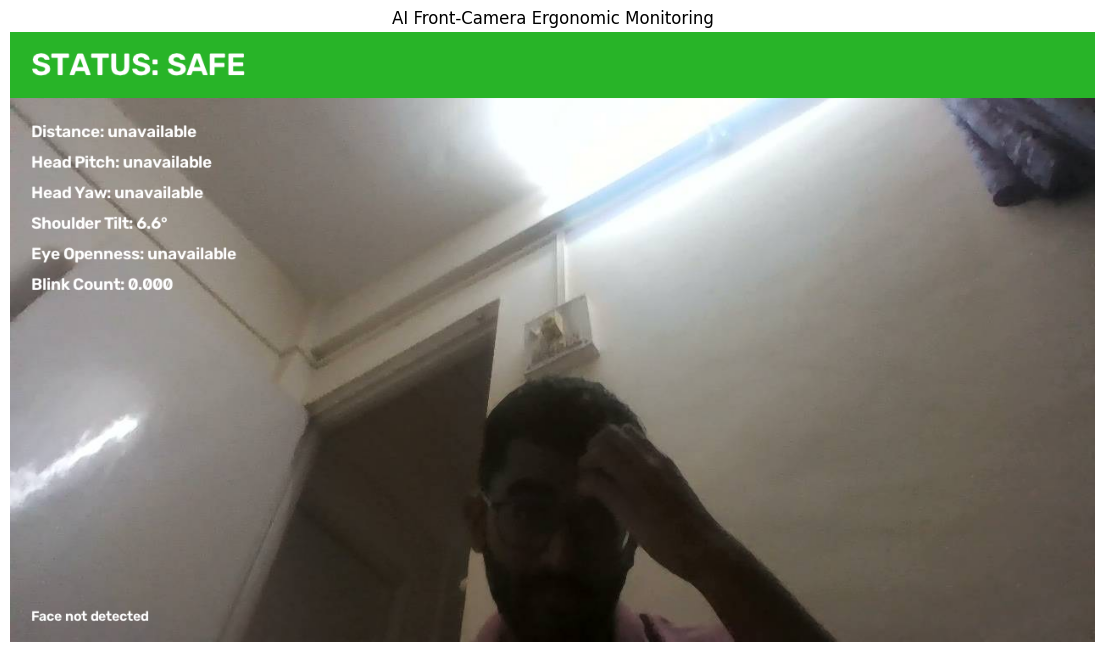

STATUS       : SAFE
Distance     : nan cm
Head pitch   : nan°
Head yaw     : nan°
Shoulder     : 6.6°
Eye openness : nan
Blink count  : 0
Attention    : Face not detected


In [ ]:
# ============================================================
# NB3 - CELL 17
# SPONSOR LIVE MONITORING
# ============================================================

TARGET_FPS = 30

# Process 2 frames per browser call.
BATCH_SIZE = 2

BATCH_SECONDS = (
    BATCH_SIZE /
    TARGET_FPS
)


sponsor_temporal = SponsorTemporalState(
    warning_seconds=FINAL_POLICY[
        "temporal"
    ]["warning_seconds"],
    non_safe_seconds=FINAL_POLICY[
        "temporal"
    ]["non_safe_seconds"]
)

# Reset blink state
pipeline.blink_count = 0
pipeline.eyes_closed = False
pipeline.closure_start = None
pipeline.last_blink_time = None


print("=" * 75)
print("NB3 - LIVE SPONSOR DEMONSTRATION")
print("=" * 75)

print(
    f"Target inference: ~{TARGET_FPS} FPS"
)

print(
    "Press the Colab interrupt button to stop."
)

try:

    while True:

        batch_start = time.time()

        # ----------------------------------------------------
        # Capture a batch
        # ----------------------------------------------------

        frames = capture_live_batch(
            frame_count=BATCH_SIZE,
            fps=TARGET_FPS
        )

        # ----------------------------------------------------
        # Process each frame
        # ----------------------------------------------------

        for frame in frames:

            timestamp = time.time()

            result = pipeline.process_frame(
                frame
            )

            decision = sponsor_decision(
                result,
                timestamp
            )

            annotated = (
                annotate_sponsor_frame(
                    frame,
                    result,
                    decision
                )
            )

        # ----------------------------------------------------
        # Show the latest frame
        # ----------------------------------------------------

        clear_output(
            wait=True
        )

        plt.figure(
            figsize=(14, 8)
        )

        plt.imshow(
            cv2.cvtColor(
                annotated,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.axis("off")

        plt.title(
            "AI Front-Camera Ergonomic Monitoring"
        )

        plt.show()

        # ----------------------------------------------------
        # Compact sponsor information
        # ----------------------------------------------------

        print(
            f"STATUS       : "
            f"{decision['final_status']}"
        )

        print(
            f"Distance     : "
            f"{result.get('estimated_distance_cm', np.nan):.1f} cm"
        )

        print(
            f"Head pitch   : "
            f"{result.get('head_pitch_deg', np.nan):.1f}°"
        )

        print(
            f"Head yaw     : "
            f"{result.get('head_yaw_deg', np.nan):.1f}°"
        )

        print(
            f"Shoulder     : "
            f"{result.get('shoulder_tilt_deg', np.nan):.1f}°"
        )

        print(
            f"Eye openness : "
            f"{result.get('mean_eye_open_ratio', np.nan):.3f}"
        )

        print(
            f"Blink count  : "
            f"{result.get('blink_count', 0)}"
        )

        if decision["reasons"]:

            print(
                "Attention    :",
                " | ".join(
                    decision["reasons"]
                )
            )

        # ----------------------------------------------------
        # Don't exceed CPU unnecessarily
        # ----------------------------------------------------

        elapsed = (
            time.time() -
            batch_start
        )

        target_time = BATCH_SECONDS

        remaining = (
            target_time -
            elapsed
        )

        if remaining > 0:
            time.sleep(
                remaining
            )


except KeyboardInterrupt:

    print(
        "\nLive monitoring stopped."
    )